In [18]:
import sys
from pathlib import Path

PROJECT_ROOT = Path().resolve().parent
sys.path.append(str(PROJECT_ROOT))

In [19]:
from src.data.load_data import load_ratings, load_movies
import pandas as pd

In [20]:
ratings = load_ratings()
movies = load_movies()

In [21]:
ratings.head()

,userId,movieId,rating,timestamp
0,1,2,3.5,2005-04-02 23:53:47
1,1,29,3.5,2005-04-02 23:31:16
2,1,32,3.5,2005-04-02 23:33:39
3,1,47,3.5,2005-04-02 23:32:07
4,1,50,3.5,2005-04-02 23:29:40


In [22]:
ratings.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000263 entries, 0 to 20000262
Data columns (total 4 columns):
 #   Column     Dtype  
---  ------     -----  
 0   userId     int64  
 1   movieId    int64  
 2   rating     float64
 3   timestamp  object 
dtypes: float64(1), int64(2), object(1)
memory usage: 610.4+ MB


📌 Insight: Incorrect data type for timestamp
The timestamp column is stored as object, while it actually represents Unix time.
This is a data quality issue, since timestamps should be in a numerical or datetime format for proper analysis.

In [23]:
ratings.isnull().sum()

userId       0
movieId      0
rating       0
timestamp    0
dtype: int64

In [24]:
ratings["timestamp"] = pd.to_datetime(ratings["timestamp"])

In [25]:
ratings["rating"].value_counts().sort_index()

rating
0.5     239125
1.0     680732
1.5     279252
2.0    1430997
2.5     883398
3.0    4291193
3.5    2200156
4.0    5561926
4.5    1534824
5.0    2898660
Name: count, dtype: int64

<Axes: >

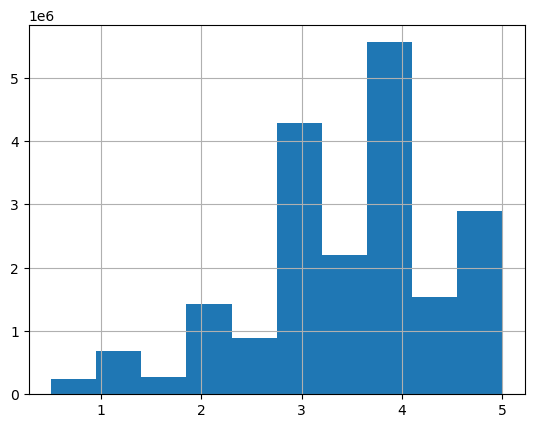

In [26]:
ratings["rating"].hist(bins=10)

📌Insight 
The distribution of ratings shows that 4.0 is the most frequently given score, followed by 3.0 and 5.0. This suggests that users tend to give relatively high ratings overall, rather than neutral or low ones.

In addition, we can observe that:
- Low ratings (0.5–2.0) are significantly less common,
- The distribution is skewed toward higher values.

In [27]:
n_users = ratings["userId"].nunique()
n_movies = ratings["movieId"].nunique()

n_users, n_movies

(138493, 26744)

In [28]:
# Average number of ratings per user
ratings_per_user = ratings.groupby("userId").size()
ratings_per_user.mean()

144.4135299257002

In [29]:
# Average rating per movie
ratings_per_movie = ratings.groupby("movieId").size()
ratings_per_movie.mean()

747.8411232425965

📌Insight: User and item interaction density
On average, each user has rated ~144 movies, while each movie has received ~748 ratings.

Despite relatively high averages, the data is still expected to follow a long-tail distribution:
- A small number of users are very active
- A small number of movies are extremely popular
- The majority have far fewer interactions

In [30]:
ratings_per_user.describe()

count    138493.000000
mean        144.413530
std         230.267257
min          20.000000
25%          35.000000
50%          68.000000
75%         155.000000
max        9254.000000
dtype: float64

In [31]:
ratings_per_movie.describe()

count    26744.000000
mean       747.841123
std       3085.818268
min          1.000000
25%          3.000000
50%         18.000000
75%        205.000000
max      67310.000000
dtype: float64

<Axes: >

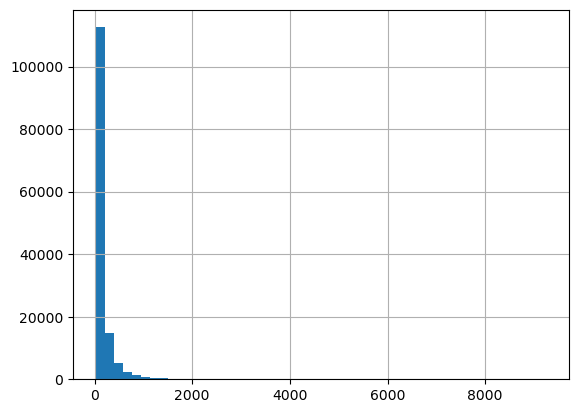

In [32]:
ratings_per_user.hist(bins=50)

📌 Insight: 
The dataset is highly imbalanced in terms of user engagement - even though the average number of ratings per user is relatively high ~144, 
the median is much lower ~68, which indicates a skewed distribution.
A small number of users are extremely active (up to 9000+ ratings)   
User activity follows a **long-tail distribution** 

🎯 Why it matters
Users with few ratings → harder to model (cold-start-like behavior)   
Highly active users → dominate the learned patterns   
    
This can lead to:
Reduced recommendation quality for low-activity users   
Bias toward patterns from heavy users

In [33]:
num_ratings = len(ratings)
num_ratings

20000263

In [34]:
sparsity = 1 - num_ratings / (n_users * n_movies)
sparsity

0.9946001521864456

📌Insight: Extreme sparsity of the interaction matrix - approximately 99.5%
The user-item matrix contains ~138K users and ~26K movies, but only ~20M observed ratings.
Almost all possible user–movie pairs are missing.

🎯 Why it matters
Memory-based collaborative filtering (user-user / item-item similarity) becomes unreliable due to lack of overlap.
Matrix factorization methods (SVD, ALS) are more suitable because they learn latent representations instead of relying on direct overlap.

# (Content-Based Perspective)
EDA for Content-Based Filtering 

In [35]:
movies.head()

,movieId,title,genres
0,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy
1,2,Jumanji (1995),Adventure|Children|Fantasy
2,3,Grumpier Old Men (1995),Comedy|Romance
3,4,Waiting to Exhale (1995),Comedy|Drama|Romance
4,5,Father of the Bride Part II (1995),Comedy


In [36]:
movies.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 27278 entries, 0 to 27277
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   movieId  27278 non-null  int64 
 1   title    27278 non-null  object
 2   genres   27278 non-null  object
dtypes: int64(1), object(2)
memory usage: 639.5+ KB


In [37]:
movies.isnull().sum()

movieId    0
title      0
genres     0
dtype: int64

In addition to user-item interactions, we analyze movie metadata
to understand whether content-based filtering is feasible.

We focus on:
- Genres (main feature)
- Title (for potential text features)
- Release year (derived feature)

In [38]:
#🔍 Do genres exist and are they usable?
(movies["genres"] == "(no genres listed)").sum()

246

Some movies do not contain genre information.

In [57]:
movies["genres"] = movies["genres"].fillna("")
movies["genres"] = movies["genres"].apply(lambda x: x.replace("|", " "))

In [58]:
from collections import Counter

all_genres = " ".join(movies["genres"]).split()
Counter(all_genres).most_common(10)

[('Drama', 13344),
 ('Comedy', 8374),
 ('Thriller', 4178),
 ('Romance', 4127),
 ('Action', 3520),
 ('Crime', 2939),
 ('Horror', 2611),
 ('Documentary', 2471),
 ('Adventure', 2329),
 ('Sci-Fi', 1743)]

Certain genres dominate the dataset (e.g., Drama, Comedy, Documentary).

- Popular genres → less discriminative
- Rare genres → stronger signal

In [40]:
# 🔍 Do release years exist?
# ❌ Initial attempt (has issues with titles like "1000 Years from Now")
import re

def extract_year(title):
    match = re.search(r"\((\d{4})", title)
    if match:
        return int(match.group(1))
    return None


In [41]:
movies["year"] = movies["title"].apply(extract_year)
movies["year"].describe()

count    27259.000000
mean      1989.326534
std         24.141496
min       1000.000000
25%       1976.000000
50%       1998.000000
75%       2008.000000
max       2015.000000
Name: year, dtype: float64

Most movies have extracted release years, although some invalid values (e.g., year=1000) indicate noise in the data.
This still allows us to create temporal features after cleaning.

We hypothesize that:
- Movies from similar eras share stylistic patterns
- This may improve content similarity

In [42]:
movies[movies["year"] == 1000]["title"]

22287    Captive Women (1000 Years from Now) (3000 A.D....
Name: title, dtype: object

The initial approach incorrectly extracted non-release numbers (e.g., "1000 Years from Now").
We improved the function by:
- Extracting all 4-digit numbers in parentheses
- Selecting the last valid year within a realistic range

In [43]:
# ✅ Improved version: takes last valid year in parentheses
def extract_year(title):
    matches = re.findall(r"\((\d{4})\)", title)
    for year in reversed(matches):
        year = int(year)
        if 1880 <= year <= 2025:
            return year
    return None

In [44]:
movies["year"] = movies["title"].apply(extract_year)
movies["year"].describe()

count    27256.000000
mean      1989.371551
std         23.335631
min       1891.000000
25%       1976.000000
50%       1998.000000
75%       2008.000000
max       2015.000000
Name: year, dtype: float64

In [45]:
movies[movies["year"] == 1891]["title"]

27015    Dickson Greeting (1891)
Name: title, dtype: object

<Axes: >

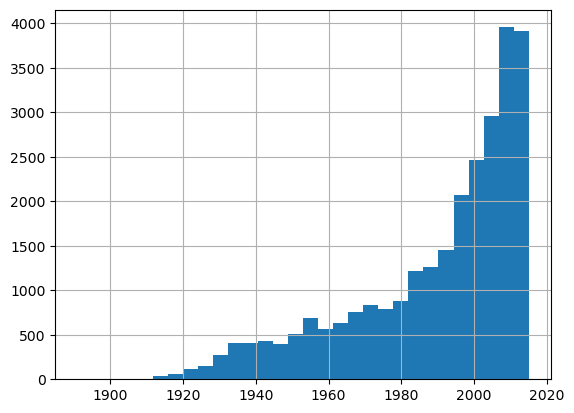

In [46]:
#🔍 Year distribution
movies["year"].hist(bins=30)

In [47]:
#🔍 Year groups
import pandas as pd
def year_group(year):
    if pd.isna(year):
        return "unknown"
    elif year < 1990:
        return "old"
    elif year < 2005:
        return "classic"
    elif year < 2015:
        return "modern"
    else:
        return "new"

movies["year_group"] = movies["year"].apply(year_group)
movies["year_group"].value_counts()

year_group
old        10138
modern      9341
classic     7657
new          120
unknown       22
Name: count, dtype: int64

The dataset is dominated by 'old' and 'modern' movies,
while very recent movies are underrepresented.


## 👁️‍🗨️ tags.csv

In [48]:
from src.data.load_data import load_tags

tags = load_tags()
tags.head()

,userId,movieId,tag,timestamp
0,18,4141,Mark Waters,2009-04-24 18:19:40
1,65,208,dark hero,2013-05-10 01:41:18
2,65,353,dark hero,2013-05-10 01:41:19
3,65,521,noir thriller,2013-05-10 01:39:43
4,65,592,dark hero,2013-05-10 01:41:18


In [49]:
tags.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 465564 entries, 0 to 465563
Data columns (total 4 columns):
 #   Column     Non-Null Count   Dtype 
---  ------     --------------   ----- 
 0   userId     465564 non-null  int64 
 1   movieId    465564 non-null  int64 
 2   tag        465548 non-null  object
 3   timestamp  465564 non-null  object
dtypes: int64(2), object(2)
memory usage: 14.2+ MB


In [50]:
tags.isnull().sum()

userId        0
movieId       0
tag          16
timestamp     0
dtype: int64

In [51]:
movie_tags = (
    tags.groupby("movieId")["tag"]
    .apply(lambda x: " ".join(x.astype(str)))
    .reset_index()
)

movie_tags.columns = ["movieId", "user_tags"]
movie_tags.head()

,movieId,user_tags
0,1,Watched computer animation Disney animated fea...
1,2,time travel adapted from:book board game child...
2,3,old people that is actually funny sequel fever...
3,4,chick flick revenge characters chick flick cha...
4,5,Diane Keaton family sequel Steve Martin weddin...


We aggregate user-generated tags for each movie.
All tags assigned to the same movie are grouped by movieId and concatenated into a single string. This allows us to represent each movie as a bag-of-words style text feature based on user tags.

In [52]:
movies = movies.merge(movie_tags, on="movieId", how="left")
movies.head()

,movieId,title,genres,year,year_group,user_tags
0,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy,1995.0,classic,Watched computer animation Disney animated fea...
1,2,Jumanji (1995),Adventure|Children|Fantasy,1995.0,classic,time travel adapted from:book board game child...
2,3,Grumpier Old Men (1995),Comedy|Romance,1995.0,classic,old people that is actually funny sequel fever...
3,4,Waiting to Exhale (1995),Comedy|Drama|Romance,1995.0,classic,chick flick revenge characters chick flick cha...
4,5,Father of the Bride Part II (1995),Comedy,1995.0,classic,Diane Keaton family sequel Steve Martin weddin...


In [59]:
movies["content"] = (movies["genres"] + " "
                     + movies["user_tags"])
movies.head()

,movieId,title,genres,year,year_group,user_tags,content
0,1,Toy Story (1995),Adventure Animation Children Comedy Fantasy,1995.0,classic,Watched computer animation Disney animated fea...,Adventure Animation Children Comedy Fantasy Wa...
1,2,Jumanji (1995),Adventure Children Fantasy,1995.0,classic,time travel adapted from:book board game child...,Adventure Children Fantasy time travel adapted...
2,3,Grumpier Old Men (1995),Comedy Romance,1995.0,classic,old people that is actually funny sequel fever...,Comedy Romance old people that is actually fun...
3,4,Waiting to Exhale (1995),Comedy Drama Romance,1995.0,classic,chick flick revenge characters chick flick cha...,Comedy Drama Romance chick flick revenge chara...
4,5,Father of the Bride Part II (1995),Comedy,1995.0,classic,Diane Keaton family sequel Steve Martin weddin...,Comedy Diane Keaton family sequel Steve Martin...


We merge the aggregated user tags with the main movies dataset using a left join on movieId, ensuring that all movies are retained even if they have no user tags. Missing values in the user_tags column are then replaced with empty strings to avoid null values in later text processing steps.